In [8]:
import stlrom
from stlrom import Signal, SignalGen, OscillSignalGen, PWCSignalGen
import matplotlib.pyplot as plt
import numpy as np

step_gen = PWCSignalGen()
osc_gen  = OscillSignalGen()


<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

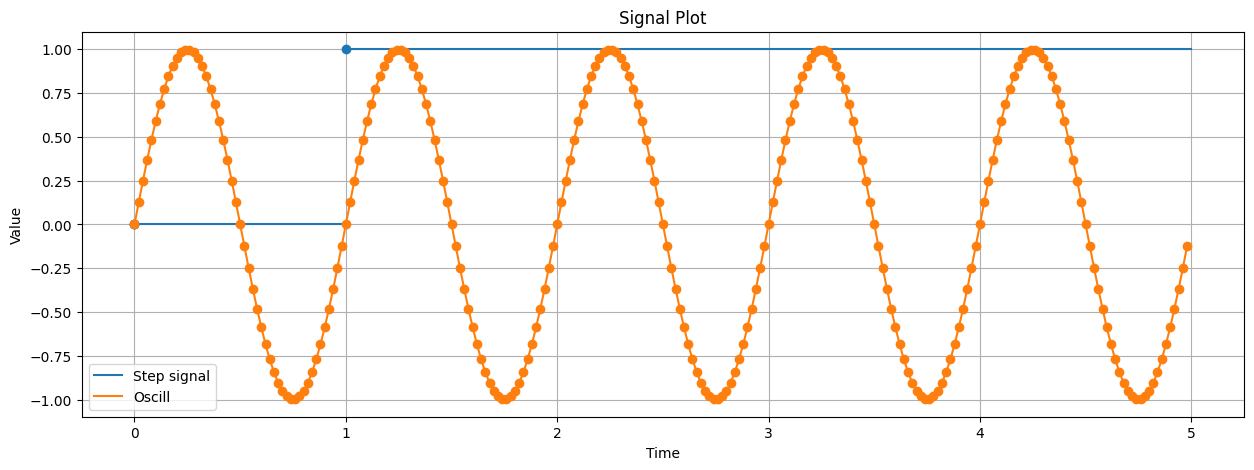

In [9]:
step_sig = step_gen.get_signal(t0=0, tf=5)
ax = step_sig.plot(label= 'Step signal')
sin_sig = osc_gen.get_signal(dt=0.02, tf=5)
sin_sig.plot(ax=ax, label='Oscill')


In [10]:
driver = stlrom.STLDriver()
driver.parse_string('signal step, sin')
driver.parse_string('mu_step := step[t]>0')
driver.parse_string('mu_sin := sin[t]>0')
driver.parse_string('mu_and := mu_step and mu_sin')
driver.parse_string('mu_or := mu_step or mu_sin')
driver.parse_string('phi := mu_and until[0,1] mu_or')

print(driver)

# STLDriver object defined as
signal sin, step

# With formulas
mu_and:= step[t] > 0 and sin[t] > 0
mu_or:= step[t] > 0 or sin[t] > 0
mu_sin:= sin[t] > 0
mu_step:= step[t] > 0
phi:=  (step[t] > 0 and sin[t] > 0) until_[0,1] (step[t] > 0 or sin[t] > 0) 

# Data:
No data yet.


In [11]:
driver.set_signals([step_sig, sin_sig])

print(driver)

# STLDriver object defined as
signal sin, step

# With formulas
mu_and:= step[t] > 0 and sin[t] > 0
mu_or:= step[t] > 0 or sin[t] > 0
mu_sin:= sin[t] > 0
mu_step:= step[t] > 0
phi:=  (step[t] > 0 and sin[t] > 0) until_[0,1] (step[t] > 0 or sin[t] > 0) 

# Data:

# Signal sin:
250 samples from t0=0 to t_end=5

# Signal step:
3 samples from t0=0 to t_end=5



t: 0 vt: -1e-10 dt: 6.26666vL: 0 vR: 0dL: 6.26666 dR: 0


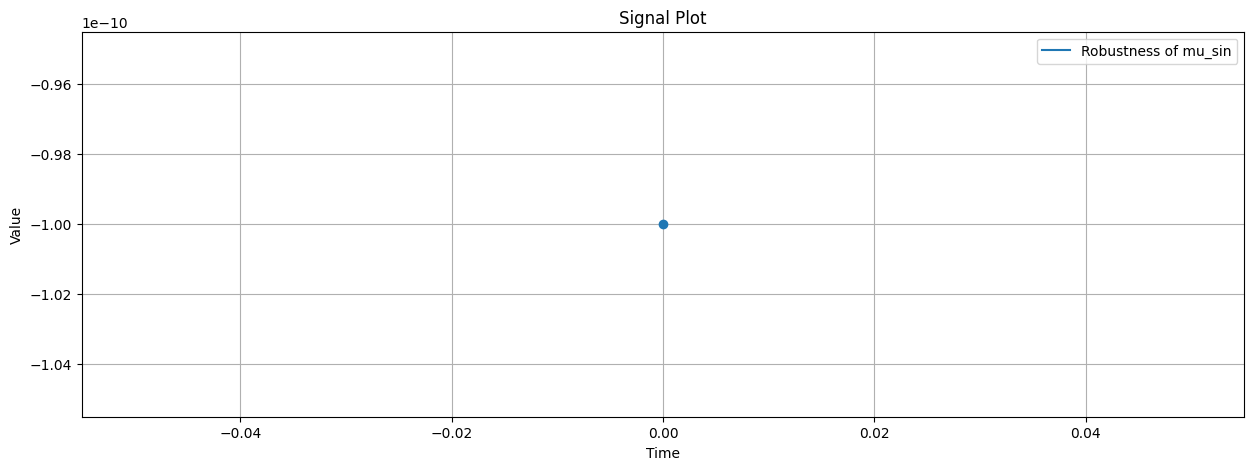

In [ ]:
Signal.set_BigM(2)

rob = driver.get_monitor("mu_sin").eval_online_rob( 0, 5)
ax = rob[0].plot(label='Robustness of mu_sin')
# ax = rob[1].plot(ax=ax, label='Lower bound of robustness of mu_sin')
# ax = rob[2].plot(ax=ax, label='Upper bound of robustness of mu_sin')

t: 0 vt: -1e-10 dt: 0vL: 0 vR: 0dL: 0 dR: 0
t: 0 vt: -1e-10 dt: 0vL: 0 vR: 0dL: 0 dR: 0
t: 1 vt: 1 dt: 0vL: 1 vR: 0dL: 0 dR: 0
t: 5 vt: 1 dt: 0vL: 1 vR: 0dL: 0 dR: 0
t: 0 vt: -1e-10 dt: 6.26666vL: 0 vR: 0dL: 6.26666 dR: 0
t: 0.02 vt: 0.125333 dt: 6.16783vL: 0.125333 vR: 0dL: 6.16783 dR: 0
t: 0.04 vt: 0.24869 dt: 5.97173vL: 0.24869 vR: 0dL: 5.97173 dR: 0
t: 0.06 vt: 0.368125 dt: 5.68146vL: 0.368125 vR: 0dL: 5.68146 dR: 0
t: 0.08 vt: 0.481754 dt: 5.30158vL: 0.481754 vR: 0dL: 5.30158 dR: 0
t: 0.1 vt: 0.587785 dt: 4.83809vL: 0.587785 vR: 0dL: 4.83809 dR: 0
t: 0.12 vt: 0.684547 dt: 4.29831vL: 0.684547 vR: 0dL: 4.29831 dR: 0
t: 0.14 vt: 0.770513 dt: 3.69073vL: 0.770513 vR: 0dL: 3.69073 dR: 0
t: 0.16 vt: 0.844328 dt: 3.02496vL: 0.844328 vR: 0dL: 3.02496 dR: 0
t: 0.18 vt: 0.904827 dt: 2.31147vL: 0.904827 vR: 0dL: 2.31147 dR: 0
t: 0.2 vt: 0.951057 dt: 1.56154vL: 0.951057 vR: 0dL: 1.56154 dR: 0
t: 0.22 vt: 0.982287 dt: 0.786974vL: 0.982287 vR: 0dL: 0.786974 dR: 0
t: 0.24 vt: 0.998027 dt: 0vL: 0.

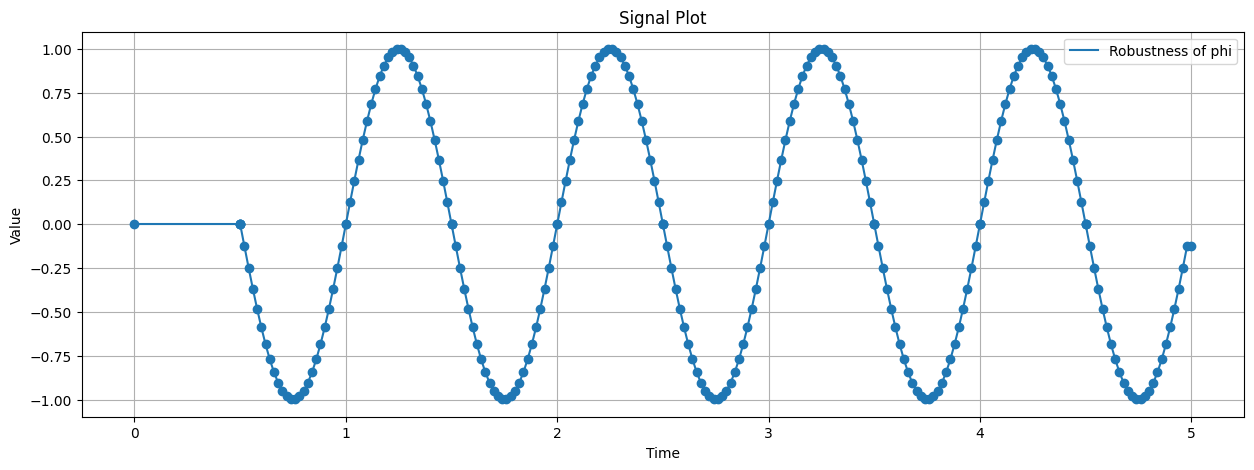

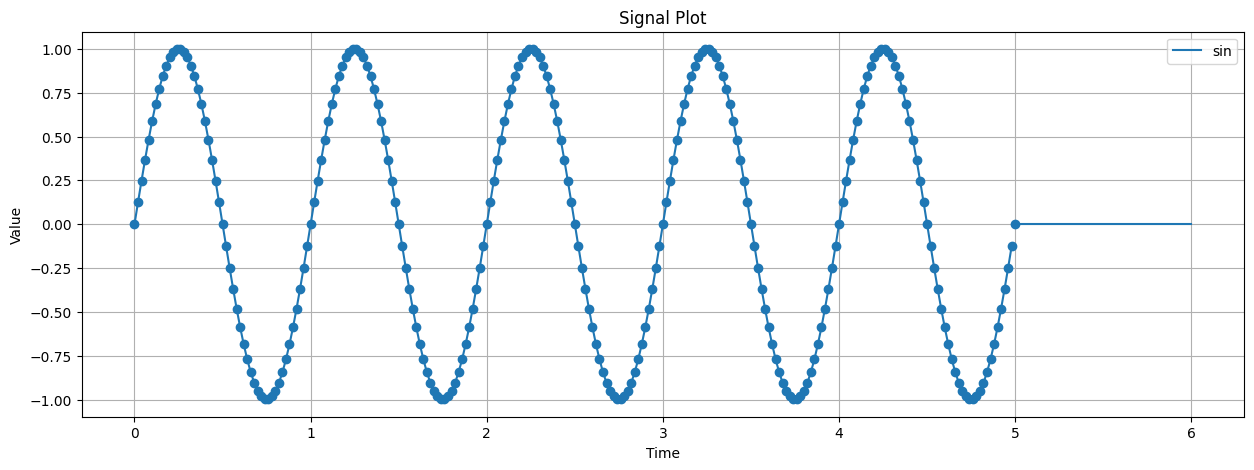

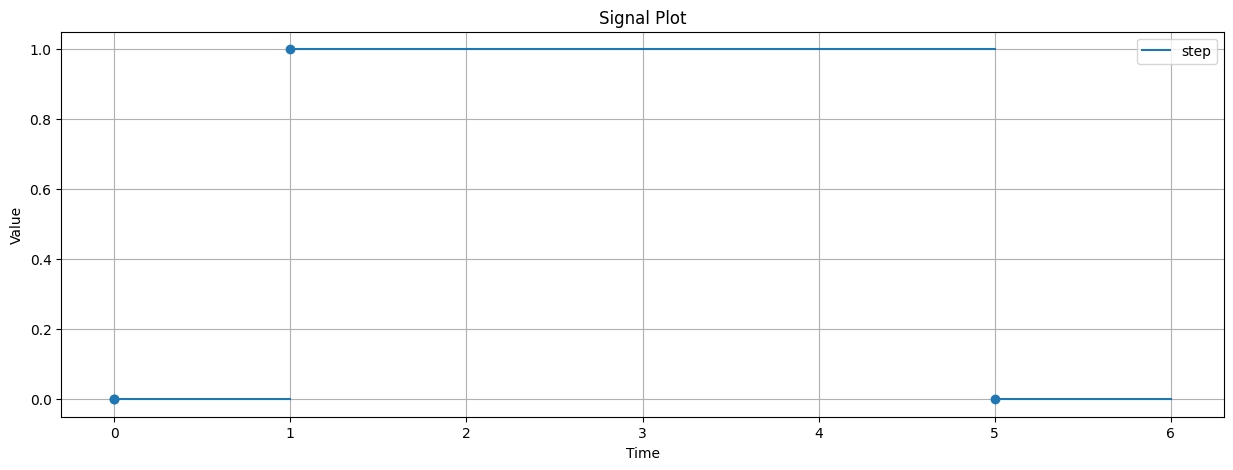

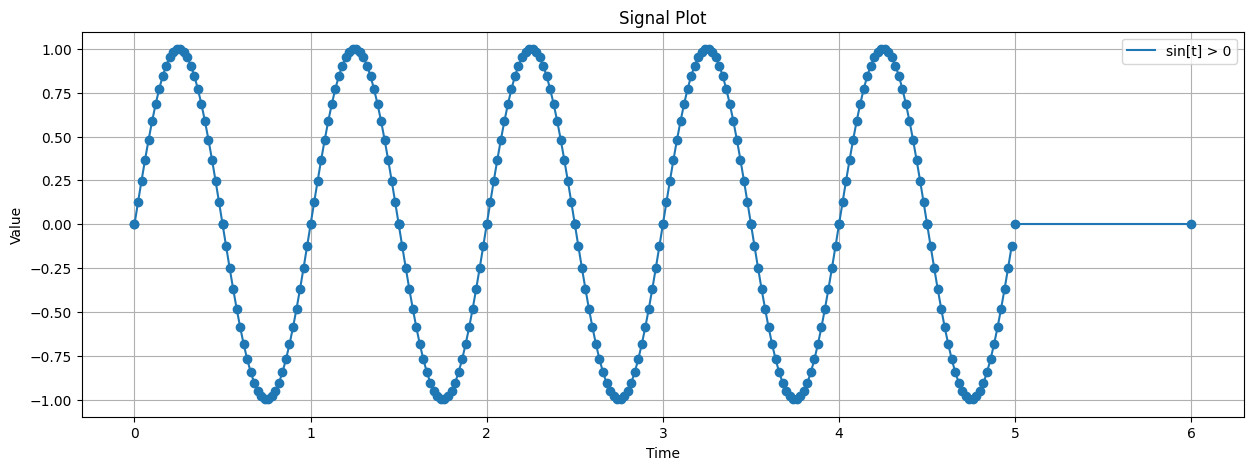

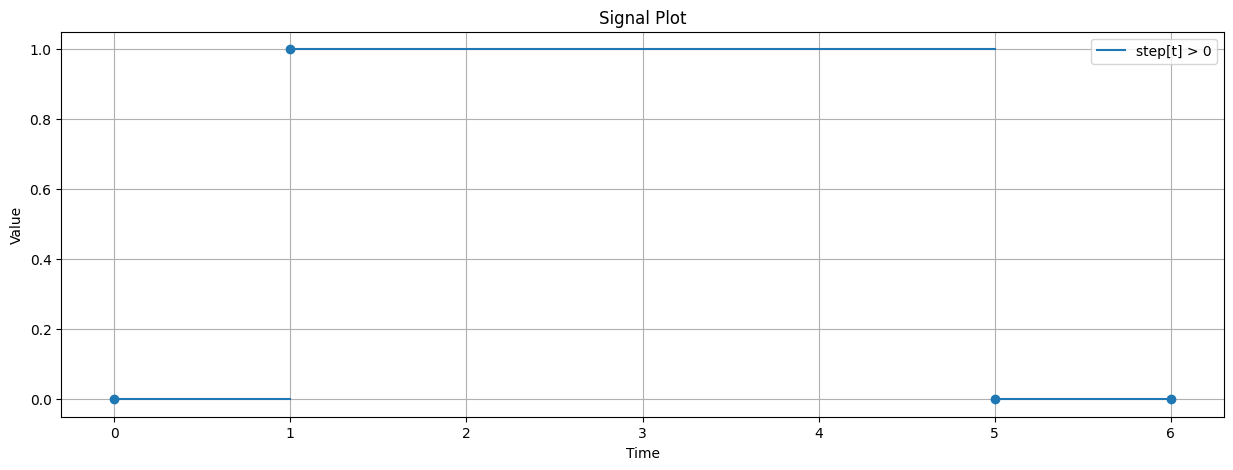

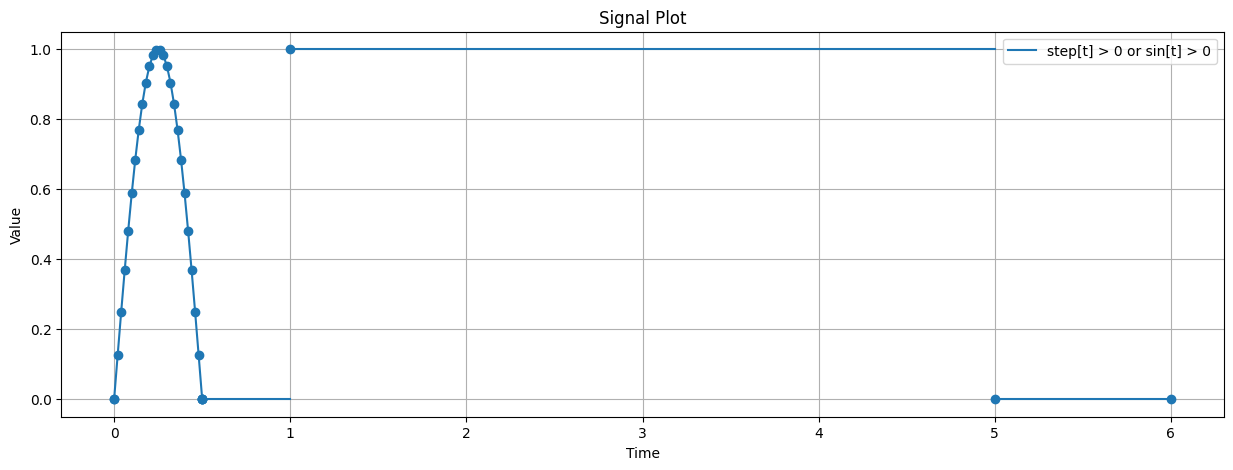

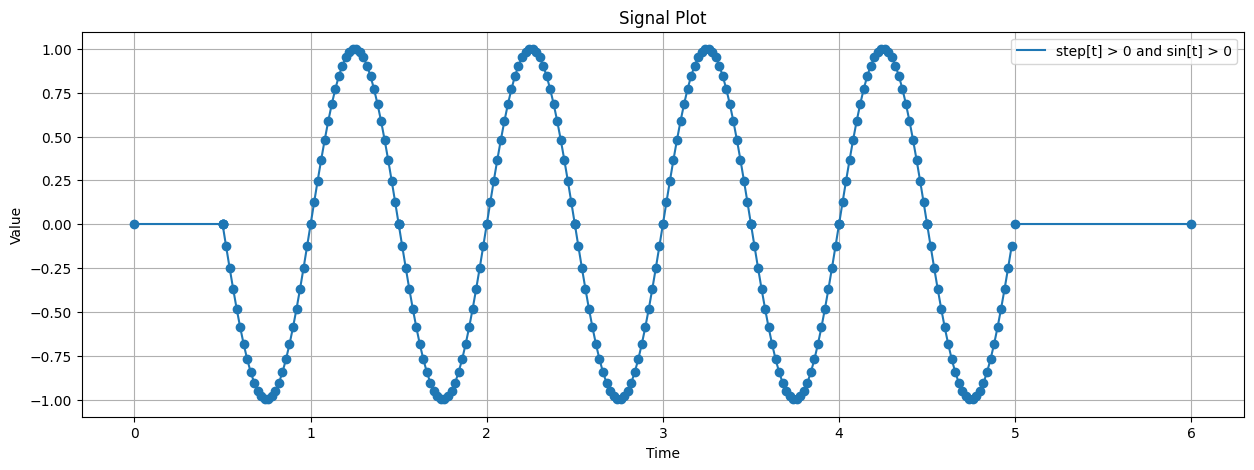

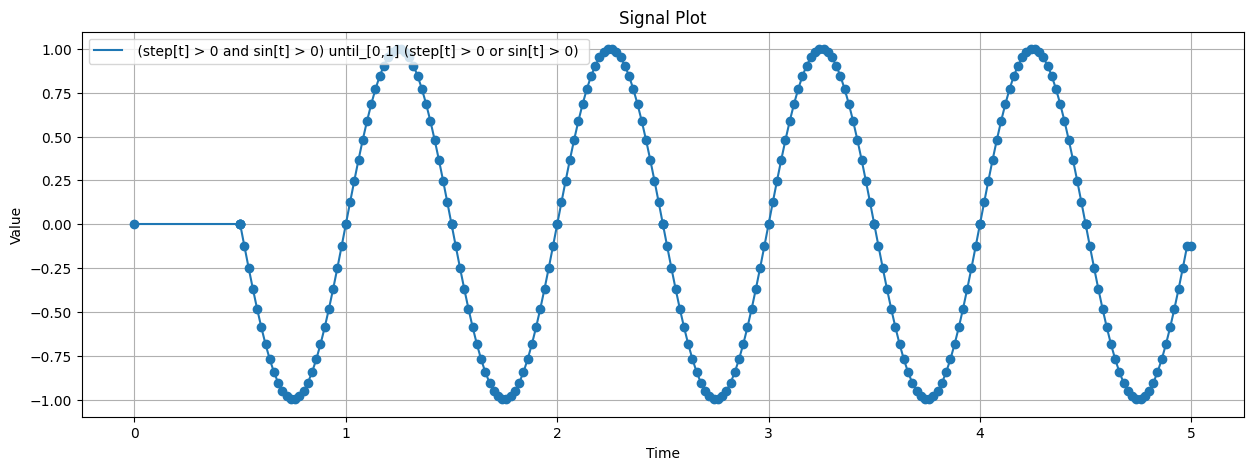

In [15]:
z = driver.eval_rob("phi", 0, 4)
z.plot(label='Robustness of phi')

rob_map = driver.get_robustness_map("phi")
print(rob_map)


ax = None

for key in sorted(rob_map, key=len):
    rob_map[key].plot(label=key, ax=ax)

t: 0 vt: 1e-10 dt: 0vL: 0 vR: 0dL: 0 dR: 0


<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

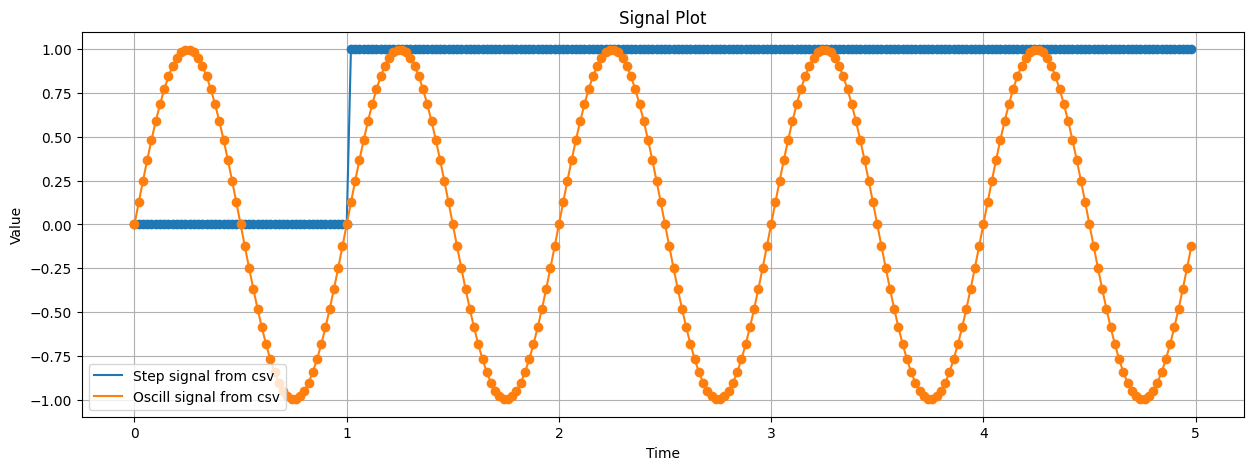

In [14]:
# testing writing and loading csv
driver.write_csv('test_signals.csv')


driver2 = stlrom.STLDriver()
driver2.parse_string('signal step, sin')
driver2.parse_string('mu_step := step[t]==0')
driver2.parse_string('mu_sin := sin[t]==0')
driver2.load_csv('test_signals.csv')

driver2.get_rob('mu_step', 0)

ax2 = driver2.data[0].plot(label='Step signal from csv')
driver2.data[1].plot(ax=ax2, label='Oscill signal from csv')